In [ ]:
!pip install nltk spacy gensim scikit-learn pandas numpy matplotlib wordcloud plotly transformers
!python -m spacy download en_core_web_sm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 64.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import nltk, re, spacy, pandas as pd, numpy as np
from nltk.corpus import stopwords
from gensim import corpora, models
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import plotly.express as px
from transformers import pipeline

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
nlp = spacy.load("en_core_web_sm")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from google.colab import files
!pip install python-docx
!pip install PyMuPDF
import docx
import fitz  # PyMuPDF

uploaded = files.upload()

filename = list(uploaded.keys())[0]
text_data = ""

if filename.endswith('.txt'):
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            text_data = f.read()
    except UnicodeDecodeError:
        with open(filename, 'r', encoding='latin-1') as f:
            text_data = f.read()

elif filename.endswith('.csv'):
    df = pd.read_csv(filename)
    text_data = ' '.join(df.astype(str).values.flatten())

elif filename.endswith('.docx'):
    doc = docx.Document(filename)
    text_data = ' '.join([para.text for para in doc.paragraphs])

elif filename.endswith('.pdf'):
    text_pages = []
    with fitz.open(filename) as pdf:
        for page in pdf:
            text_pages.append(page.get_text("text"))
    text_data = ' '.join(text_pages)

else:
    print("Unsupported file format.")

print("✅ File processed successfully!")
print("\nSample text preview:\n")
print(text_data[:1000])

Saving infosys_spring.txt to infosys_spring (2).txt
✅ File processed successfully!

Sample text preview:

My project, NarrativeNexus, is a text analysis platform that performs topic extraction, sentiment analysis, and summarization.
For topic modeling, I used LDA because its interpretable and suitable for unsupervised theme extraction, though Im aware models like BERTopic perform better using contextual embeddings.
For sentiment analysis, I used BERT, a transformer-based model, because it understands context better than rule-based methods like VADER.
For summarization, I used BART, which performs abstractive summarization by generating new sentences.
Overall, the pipeline takes any text and produces insights, summaries, and visualizations  a complete NLP workflow.


In [ ]:
def preprocess(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text.lower())
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc
              if token.text not in stop_words and len(token.text) > 2]
    return tokens

tokens = preprocess(text_data)
print(tokens[:50])


['project', 'narrativenexus', 'text', 'analysis', 'platform', 'perform', 'topic', 'extraction', 'sentiment', 'analysis', 'summarization', 'topic', 'modeling', 'use', 'lda', 'interpretable', 'suitable', 'unsupervised', 'theme', 'extraction', 'though', 'aware', 'model', 'like', 'bertopic', 'perform', 'well', 'use', 'contextual', 'embedding', 'sentiment', 'analysis', 'use', 'bert', 'transformer', 'base', 'model', 'understand', 'context', 'well', 'rule', 'base', 'method', 'like', 'vader', 'summarization', 'use', 'bart', 'perform', 'abstractive']


In [ ]:
def lda_model(tokens_list):
    dictionary = corpora.Dictionary([tokens_list])
    corpus = [dictionary.doc2bow(tokens_list)]
    lda = models.LdaModel(corpus, num_topics=5, id2word=dictionary, passes=10)
    return lda.print_topics(num_words=5)

topics = lda_model(tokens)
for t in topics:
    print(t)


(0, '0.022*"use" + 0.021*"summarization" + 0.021*"perform" + 0.021*"analysis" + 0.021*"text"')
(1, '0.021*"analysis" + 0.021*"summarization" + 0.021*"use" + 0.021*"perform" + 0.021*"text"')
(2, '0.021*"perform" + 0.021*"summarization" + 0.021*"use" + 0.021*"extraction" + 0.021*"platform"')
(3, '0.056*"use" + 0.043*"perform" + 0.043*"analysis" + 0.043*"summarization" + 0.030*"sentiment"')
(4, '0.021*"use" + 0.021*"analysis" + 0.021*"summarization" + 0.021*"perform" + 0.021*"text"')


In [ ]:
sentiment_pipeline = pipeline("sentiment-analysis")

sentences = text_data.split('.')[:10]
results = sentiment_pipeline(sentences)

for s, r in zip(sentences, results):
    print(f"{s.strip()} → {r}")


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


My project, NarrativeNexus, is a text analysis platform that performs topic extraction, sentiment analysis, and summarization → {'label': 'POSITIVE', 'score': 0.9841511249542236}
For topic modeling, I used LDA because its interpretable and suitable for unsupervised theme extraction, though Im aware models like BERTopic perform better using contextual embeddings → {'label': 'NEGATIVE', 'score': 0.9715274572372437}
For sentiment analysis, I used BERT, a transformer-based model, because it understands context better than rule-based methods like VADER → {'label': 'NEGATIVE', 'score': 0.9714077115058899}
For summarization, I used BART, which performs abstractive summarization by generating new sentences → {'label': 'NEGATIVE', 'score': 0.992508590221405}
Overall, the pipeline takes any text and produces insights, summaries, and visualizations  a complete NLP workflow → {'label': 'POSITIVE', 'score': 0.9981817007064819}
 → {'label': 'POSITIVE', 'score': 0.7481208443641663}


In [ ]:
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

summary = summarizer(text_data[:3000], max_length=150, min_length=40, do_sample=False)
print("🔹 Summary:\n", summary[0]['summary_text'])


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


🔹 Summary:
 Aravind Kumar wants to join Cognizant because it is a reputed global IT company. Stay calm, confident, and smile. Speak in short, clear sentences (don't overexplain). If stuck, say: “I haven’t worked on that yet, but I’m eager to learn”


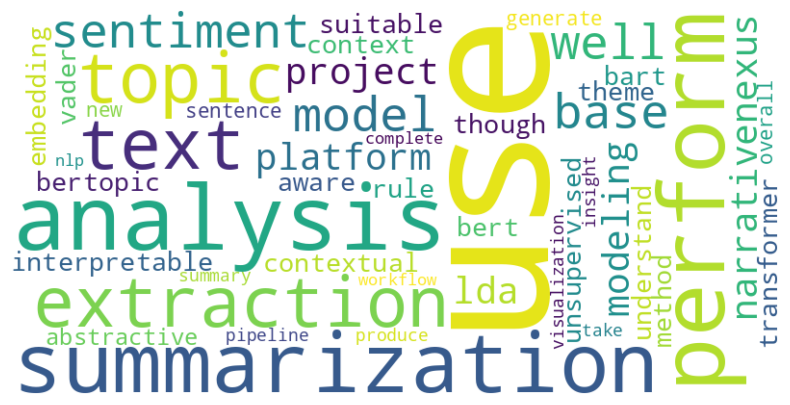

In [ ]:
wc = WordCloud(width=800, height=400, background_color='white').generate(' '.join(tokens))
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()


In [ ]:
df_sent = pd.DataFrame(results)
fig = px.bar(df_sent, x=df_sent.index, y='score', color='label',
             title='Sentiment Scores per Sentence')
fig.show()


In [ ]:
print("---- Key Insights ----")
print(f"Total Words: {len(tokens)}")
pos = sum(1 for r in results if r['label'] == 'POSITIVE')
neg = sum(1 for r in results if r['label'] == 'NEGATIVE')
neu = len(results) - (pos + neg)
print(f"Positive: {pos}, Negative: {neg}, Neutral: {neu}")
print("\nMain Topics:")
for t in topics:
    print(t)


---- Key Insights ----
Total Words: 65
Positive: 3, Negative: 3, Neutral: 0

Main Topics:
(0, '0.022*"use" + 0.021*"summarization" + 0.021*"perform" + 0.021*"analysis" + 0.021*"text"')
(1, '0.021*"analysis" + 0.021*"summarization" + 0.021*"use" + 0.021*"perform" + 0.021*"text"')
(2, '0.021*"perform" + 0.021*"summarization" + 0.021*"use" + 0.021*"extraction" + 0.021*"platform"')
(3, '0.056*"use" + 0.043*"perform" + 0.043*"analysis" + 0.043*"summarization" + 0.030*"sentiment"')
(4, '0.021*"use" + 0.021*"analysis" + 0.021*"summarization" + 0.021*"perform" + 0.021*"text"')
